# =====================================================================
#  ARIMAX(2)-GARCH(1,1) vs nested ARIMA-GARCH vs Random Walk
#  Leakage-free rolling-window forecast evaluation for IDR/USD (JISDOR)
# ---------------------------------------------------------------------

Key anti-leakage design:
* The model orders (AR(2), GARCH(1,1)) are FROZEN in advance; only the coefficients are re-estimated on each window.
* Each window uses ONLY observations up to the forecast origin `o`.
* For multi-step (h > 1) forecasts the exogenous variables are held at their last known level at the origin, so their future first differences are ZERO. No future macro value (FFR/BI/CPI) is ever read. This is exactly the information a real-time forecaster has.
# =====================================================================

In [2]:
import warnings; warnings.filterwarnings("ignore")
!pip install arch
import numpy as np
import pandas as pd
from arch.univariate import ARX, GARCH
from arch.unitroot import ADF, PhillipsPerron
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

np.random.seed(42)  # reproducibility (QMLE is deterministic; kept for parity)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 8.1 MB/s eta 0:00:00


# ---------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------

In [5]:
from google.colab import files
uploaded = files.upload()

Saving merged_data_clean.csv to merged_data_clean.csv


In [6]:
DATA_FILE = "merged_data_clean.csv"          # columns: date, fx, ffr, bi, cpi
df = pd.read_csv(DATA_FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# ---------------------------------------------------------------------
# 2. Preprocessing: stationary transforms
fx  -> log-return (in %), I(0)
exogenous (I(1)) -> first difference
# ---------------------------------------------------------------------

In [7]:
df["logret"] = np.log(df["fx"]).diff() * 100.0
for c in ["ffr", "bi", "cpi"]:
    df["d_" + c] = df[c].diff()

data = df.dropna().copy()
y    = data["logret"].to_numpy()
Xz   = data[["d_ffr", "d_bi", "d_cpi"]].to_numpy()
lvl  = data["fx"].to_numpy()
n    = len(data)

print("=" * 70)
print("DATA SUMMARY")
print("=" * 70)
print(f"Aligned observations : {n}")
print(f"Sample period        : {data.index[0].date()}  to  {data.index[-1].date()}")
print(f"Max fx               : {lvl.max():.0f}  on {data.index[int(np.argmax(lvl))].date()}")
print(f"Min fx               : {lvl.min():.0f}  on {data.index[int(np.argmin(lvl))].date()}")

DATA SUMMARY
Aligned observations : 2003
Sample period        : 2018-04-03  to  2026-07-27
Max fx               : 18171  on 2026-06-08
Min fx               : 13612  on 2020-01-27


# ---------------------------------------------------------------------
# 3. Stationarity tests (Table 2): ADF & PP on level and first difference
# ---------------------------------------------------------------------

In [8]:
print("\n" + "=" * 70)
print("TABLE 2  Unit-root tests (p-values)")
print("=" * 70)
print(f"{'Series':<18}{'ADF lvl':>9}{'PP lvl':>9}{'ADF d':>9}{'PP d':>9}{'  Order':>8}")
def pp_pair(level_series, name):
    lv = level_series.dropna().to_numpy()
    dv = np.diff(lv)
    adf_l = ADF(lv).pvalue;  pp_l = PhillipsPerron(lv).pvalue
    adf_d = ADF(dv).pvalue;  pp_d = PhillipsPerron(dv).pvalue
    order = "I(1)" if (adf_l > 0.05 and adf_d < 0.05) else "check"
    print(f"{name:<18}{adf_l:>9.4f}{pp_l:>9.4f}{adf_d:>9.4f}{pp_d:>9.4f}{order:>8}")
pp_pair(np.log(df["fx"]), "log(fx)")
for c, nm in [("ffr", "Federal Funds"), ("bi", "BI Rate"), ("cpi", "CPI")]:
    pp_pair(df[c], nm)


TABLE 2  Unit-root tests (p-values)
Series              ADF lvl   PP lvl    ADF d     PP d   Order
log(fx)              0.6641   0.6885   0.0000   0.0000    I(1)
Federal Funds        0.8531   0.8571   0.0000   0.0000    I(1)
BI Rate              0.4281   0.7380   0.0000   0.0000    I(1)
CPI                  0.9669   0.9749   0.0000   0.0000    I(1)


# ---------------------------------------------------------------------
# 4. Representative-window estimation (Table 3) + residual diagnostics (4.4)
Uses the final full window as the representative window.
# ---------------------------------------------------------------------

In [9]:
WINDOW = 1000
rep = slice(n - WINDOW, n)                       # last WINDOW observations
mrep = ARX(y[rep], lags=[1, 2], x=Xz[rep], rescale=False)
mrep.volatility = GARCH(p=1, o=0, q=1)
rres = mrep.fit(disp="off")

print("\n" + "=" * 70)
print("TABLE 3  ARIMAX(2)-GARCH(1,1) estimates (representative window)")
print("=" * 70)
print(rres.summary())

zr = np.asarray(rres.std_resid)
zr = zr[~np.isnan(zr)]
lb = acorr_ljungbox(zr, lags=[20], return_df=True)["lb_pvalue"].iloc[0]
arch_lm_p = het_arch(zr, nlags=12)[1]
jb_p = stats.jarque_bera(zr)[1]
print("\nResidual diagnostics (standardized residuals):")
print(f"  Ljung-Box(20) p = {lb:.3f}   ARCH-LM p = {arch_lm_p:.3f}   Jarque-Bera p = {jb_p:.3g}")


TABLE 3  ARIMAX(2)-GARCH(1,1) estimates (representative window)
                          AR-X - GARCH Model Results                          
Dep. Variable:                      y   R-squared:                       0.025
Mean Model:                      AR-X   Adj. R-squared:                  0.020
Vol Model:                      GARCH   Log-Likelihood:               -326.507
Distribution:                  Normal   AIC:                           671.015
Method:            Maximum Likelihood   BIC:                           715.167
                                        No. Observations:                  998
Date:                Tue, Aug 18 2026   Df Residuals:                      992
Time:                        13:05:54   Df Model:                            6
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------

# ---------------------------------------------------------------------
# 5. Rolling-window, leakage-free forecast evaluation (Table 4)
# ---------------------------------------------------------------------

In [10]:
H = [1, 5, 10, 20, 60]
err = {m: {h: [] for h in H} for m in ["arimax", "arima", "rw"]}
act = {h: [] for h in H}
exog_future = np.zeros(3)   # future FFR/BI/CPI diffs are unknown at origin -> 0

for o in range(WINDOW - 1, n - 1):              # o = index of last in-sample obs
    tr = slice(o - WINDOW + 1, o + 1)           # WINDOW obs, all indices <= o
    ytr, Xtr = y[tr], Xz[tr]

    # ARIMAX(2)-GARCH(1,1)  (full model with exogenous regressors)
    mx = ARX(ytr, lags=[1, 2], x=Xtr, rescale=False)
    mx.volatility = GARCH(p=1, o=0, q=1)
    px = mx.fit(disp="off").params.to_numpy()
    cX, a1X, a2X, bX = px[0], px[1], px[2], px[3:6]

    # ARIMA(2)-GARCH(1,1)  (nested control: same dynamics, no exogenous)
    m0 = ARX(ytr, lags=[1, 2], rescale=False)
    m0.volatility = GARCH(p=1, o=0, q=1)
    p0 = m0.fit(disp="off").params.to_numpy()
    c0, a10, a20 = p0[0], p0[1], p0[2]

    for h in H:
        if o + h > n - 1:
            continue
        # ---- ARIMAX iterated h-step forecast (exog diff = 0, no leakage) ----
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = cX + a1X * l1 + a2X * l2 + bX @ exog_future
            s += rh; l2, l1 = l1, rh
        lx = lvl[o] * np.exp(s / 100.0)
        # ---- ARIMA iterated h-step forecast ----
        l1, l2, s = y[o], y[o - 1], 0.0
        for _ in range(h):
            rh = c0 + a10 * l1 + a20 * l2
            s += rh; l2, l1 = l1, rh
        l0 = lvl[o] * np.exp(s / 100.0)
        # ---- Random walk (no-change) forecast ----
        lrw = lvl[o]

        a = lvl[o + h]
        act[h].append(a)
        err["arimax"][h].append(a - lx)
        err["arima"][h].append(a - l0)
        err["rw"][h].append(a - lrw)

# ---------------------------------------------------------------------
# 6. Metrics and Diebold-Mariano test with HLN small-sample correction
# ---------------------------------------------------------------------

In [11]:
def metrics(e, yv):
    e, yv = np.asarray(e, float), np.asarray(yv, float)
    return np.mean(np.abs(e)), np.sqrt(np.mean(e**2)), 100 * np.mean(np.abs(e / yv))

def dm_hln(e1, e2, h, loss="mae"):
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (np.abs(e1) - np.abs(e2)) if loss == "mae" else (e1**2 - e2**2)
    N = len(d); dbar = d.mean()
    v = np.mean((d - dbar) ** 2)
    for lag in range(1, h):                     # HLN uses lag length h-1
        v += 2 * np.mean((d[lag:] - dbar) * (d[:-lag] - dbar))
    dm = dbar / np.sqrt(v / N)
    adj = np.sqrt((N + 1 - 2 * h + h * (h - 1) / N) / N)
    return 2 * (1 - stats.t.cdf(abs(adj * dm), df=N - 1))   # two-sided p-value

print("\n" + "=" * 70)
print("TABLE 4  Forecast accuracy and Diebold-Mariano tests")
print("=" * 70)
print(f"{'h':>3}  {'model':<13}{'MAE':>9}{'RMSE':>9}{'MAPE%':>9}{'DMvsRW':>9}{'DMvsARIMA':>11}")
for h in H:
    yy = act[h]
    for m, lab in [("rw", "Random walk"), ("arima", "ARIMA-GARCH"), ("arimax", "ARIMAX-GARCH")]:
        mae, rmse, mape = metrics(err[m][h], yy)
        if m == "arimax":
            p_rw = dm_hln(err["arimax"][h], err["rw"][h], h)
            p_ar = dm_hln(err["arimax"][h], err["arima"][h], h)
            print(f"{h:>3}  {lab:<13}{mae:>9.2f}{rmse:>9.2f}{mape:>9.4f}{p_rw:>9.4f}{p_ar:>11.4f}")
        else:
            print(f"{h:>3}  {lab:<13}{mae:>9.2f}{rmse:>9.2f}{mape:>9.4f}{'-':>9}{'-':>11}")
    print()


TABLE 4  Forecast accuracy and Diebold-Mariano tests
  h  model              MAE     RMSE    MAPE%   DMvsRW  DMvsARIMA
  1  Random walk      41.14    55.98   0.2586        -          -
  1  ARIMA-GARCH      40.89    55.44   0.2571        -          -
  1  ARIMAX-GARCH     40.89    55.43   0.2571   0.3546     0.8560

  5  Random walk      99.13   129.93   0.6234        -          -
  5  ARIMA-GARCH      97.46   129.05   0.6138        -          -
  5  ARIMAX-GARCH     97.45   129.03   0.6137   0.0182     0.7494

 10  Random walk     148.63   189.97   0.9354        -          -
 10  ARIMA-GARCH     144.81   187.28   0.9132        -          -
 10  ARIMAX-GARCH    144.83   187.26   0.9133   0.0507     0.8493

 20  Random walk     215.73   277.59   1.3575        -          -
 20  ARIMA-GARCH     208.36   270.92   1.3157        -          -
 20  ARIMAX-GARCH    208.35   270.99   1.3156   0.1810     0.9631

 60  Random walk     419.04   501.28   2.6089        -          -
 60  ARIMA-GARCH  

# ---------------------------------------------------------------------
# 7. MAE reduction of ARIMAX-GARCH (Figure 4)
# ---------------------------------------------------------------------

In [12]:
print("=" * 70)
print("MAE reduction of ARIMAX-GARCH")
print("=" * 70)
print(f"{'h':>3}{'vs random walk':>18}{'vs ARIMA-GARCH':>18}")
for h in H:
    mae_x = np.mean(np.abs(err["arimax"][h]))
    mae_r = np.mean(np.abs(err["rw"][h]))
    mae_a = np.mean(np.abs(err["arima"][h]))
    print(f"{h:>3}{100*(mae_r-mae_x)/mae_r:>17.1f}%{100*(mae_a-mae_x)/mae_a:>17.1f}%")
print("\nNforecasts per horizon:", {h: len(act[h]) for h in H})


MAE reduction of ARIMAX-GARCH
  h    vs random walk    vs ARIMA-GARCH
  1              0.6%              0.0%
  5              1.7%              0.0%
 10              2.6%             -0.0%
 20              3.4%              0.0%
 60              8.7%             -0.3%

Nforecasts per horizon: {1: 1003, 5: 999, 10: 994, 20: 984, 60: 944}


# ---------------------------------------------------------------------
# 8. Visualization
# ---------------------------------------------------------------------

In [14]:
# ---------------------------------------------------------------------
# FIGURE 1  ---  Level of the exchange rate
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_ACTUAL = 'blue'

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(df.index, df["fx"], color=C_ACTUAL, lw=1.0)
ax.set_title("IDR/USD Exchange Rate (JISDOR), 2018-2026")
ax.set_xlabel("Date"); ax.set_ylabel("IDR per USD")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig("figure1_level.png"); plt.close(fig)

In [17]:
# ---------------------------------------------------------------------
# FIGURE 2  ---  Log-returns and squared returns (volatility clustering)
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_RET = 'red'
C_SQ = 'purple'
dates = data.index

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(dates, y, color=C_RET, lw=0.6)
a1.axhline(0, color="0.5", lw=0.6)
a1.set_title("Daily log-returns of the IDR/USD rate (%)")
a1.set_ylabel("Return (%)")
a2.plot(dates, y**2, color=C_SQ, lw=0.6)
a2.set_title("Squared daily returns (volatility clustering)")
a2.set_ylabel("Squared return (%$^2$)"); a2.set_xlabel("Date")
a2.xaxis.set_major_locator(mdates.YearLocator())
a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.savefig("figure2_returns.png"); plt.close(fig)

In [19]:
# ---------------------------------------------------------------------
# FIGURE 3  ---  Last 250 one-day-ahead forecasts: actual vs models
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define missing variables
f3_idx = list(range(WINDOW, n))
f3_actual = np.array(act[1])
f3_arimax = np.array(act[1]) - np.array(err["arimax"][1])
f3_rw = np.array(act[1]) - np.array(err["rw"][1])
C_MODEL = 'green'
C_RW = 'orange'

k = min(250, len(f3_idx))
sel = slice(len(f3_idx) - k, len(f3_idx))
d3 = dates[np.array(f3_idx)[sel]]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(d3, np.array(f3_actual)[sel], color=C_ACTUAL, lw=1.4, label="Actual")
ax.plot(d3, np.array(f3_arimax)[sel], color=C_MODEL, lw=1.0, label="ARIMAX-GARCH")
ax.plot(d3, np.array(f3_rw)[sel],     color=C_RW, lw=1.0, ls="--", label="Random walk")
ax.set_title(f"One-day-horizon (h = 1) rolling forecasts: actual vs. ARIMAX-GARCH vs. random walk (last {k} days)")
ax.set_xlabel("Date"); ax.set_ylabel("IDR/USD")
ax.legend(frameon=False, loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
fig.savefig("figure3_forecasts.png"); plt.close(fig)

Figure 4 (three lines) saved.
vs driftless RW : [np.float64(0.6), np.float64(1.7), np.float64(2.6), np.float64(3.4), np.float64(8.7)]
vs RW-with-drift: [np.float64(0.2), np.float64(0.1), np.float64(0.5), np.float64(0.3), np.float64(0.3)]
vs ARIMA (macro): [np.float64(0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.3)]


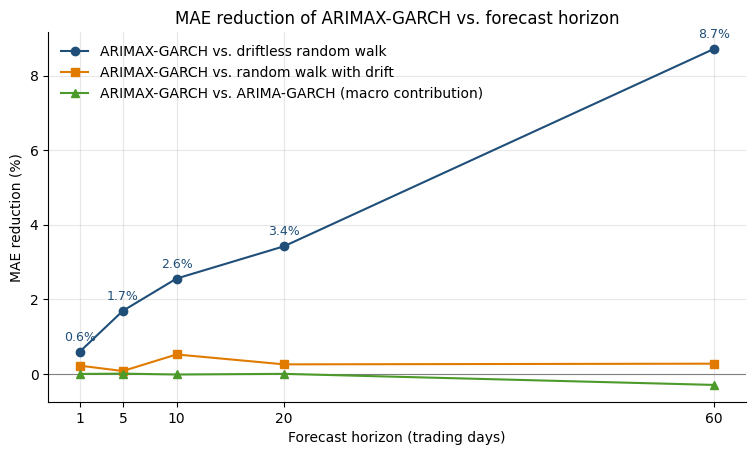

In [26]:
# ---------------------------------------------------------------------
# FIGURE 4  ---  MAE reduction of ARIMAX-GARCH vs horizon
# ---------------------------------------------------------------------
C_RW, C_DRIFT, C_MACRO = "#1f4e79", "#e07b00", "#4c9a2a"

red_rw, red_rwd, red_ar = [], [], []
for h in H:
    mae_x   = np.mean(np.abs(err["arimax"][h]))
    mae_r   = np.mean(np.abs(err["rw"][h]))
    mae_rwd = np.mean(np.abs(err_rwd[h]))
    mae_a   = np.mean(np.abs(err["arima"][h]))
    red_rw.append(100 * (mae_r - mae_x) / mae_r)
    red_rwd.append(100 * (mae_rwd - mae_x) / mae_rwd)
    red_ar.append(100 * (mae_a - mae_x) / mae_a)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(0, color="0.5", lw=0.8)
ax.plot(H, red_rw,  "-o", color=C_RW,    label="ARIMAX-GARCH vs. driftless random walk")
ax.plot(H, red_rwd, "-s", color=C_DRIFT, label="ARIMAX-GARCH vs. random walk with drift")
ax.plot(H, red_ar,  "-^", color=C_MACRO, label="ARIMAX-GARCH vs. ARIMA-GARCH (macro contribution)")
for x, v in zip(H, red_rw):                      # anotasi hanya garis atas biar tidak penuh
    ax.annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, color=C_RW)
ax.set_title("MAE reduction of ARIMAX-GARCH vs. forecast horizon")
ax.set_xlabel("Forecast horizon (trading days)"); ax.set_ylabel("MAE reduction (%)")
ax.set_xticks(H); ax.legend(frameon=False, loc="best")
ax.grid(True, alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
fig.savefig("figure4_mae_reduction.png", dpi=300, bbox_inches="tight")
print("Figure 4 (three lines) saved.")
print("vs driftless RW :", [round(v,1) for v in red_rw])
print("vs RW-with-drift:", [round(v,1) for v in red_rwd])
print("vs ARIMA (macro):", [round(v,1) for v in red_ar])


# =====================================================================
# STEP 9.  Robustness check: random walk WITH drift
# ---------------------------------------------------------------------
Added after the main analysis (Steps 1-8). The baseline random walk used above is the driftless (no-change) forecast, y_hat = last level. Because the IDR/USD rate trends upward (persistent rupiah depreciation) over the evaluation period, a stricter benchmark is a random walk WITH drift, whose h-step level forecast is
         y_hat(o+h) = level[o] * exp( h * mu / 100 ),
where mu is the mean log-return (in %) estimated ONLY on the current window (indices <= o, so no look-ahead). This checks whether the ARIMA/ARIMAX edge over the naive floor reflects genuine return/volatility dynamics or merely the estimated drift of a trending series.
Reuses variables already in memory from Steps 1-7:
   y, lvl, n, WINDOW, H, err  (err has keys 'rw', 'arima', 'arimax')
# =================================================================

In [23]:
import numpy as np
from scipy import stats

# --- 9.1 compute random-walk-with-drift forecast errors (no model fit) ---
err_rwd = {h: [] for h in H}
for o in range(WINDOW - 1, n - 1):
    mu = y[o - WINDOW + 1:o + 1].mean()          # mean log-return (%) in window, info <= o
    for h in H:
        if o + h > n - 1:
            continue
        f_rwd = lvl[o] * np.exp(h * mu / 100.0)  # RW-with-drift level forecast
        err_rwd[h].append(lvl[o + h] - f_rwd)

# --- 9.2 Diebold-Mariano test with HLN small-sample correction ---
def dm_hln(e1, e2, h, loss="mae"):
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (np.abs(e1) - np.abs(e2)) if loss == "mae" else (e1 ** 2 - e2 ** 2)
    N = len(d); dbar = d.mean(); g0 = np.mean((d - dbar) ** 2); v = g0
    for lag in range(1, h):
        v += 2 * np.mean((d[lag:] - dbar) * (d[:-lag] - dbar))
    if v <= 0:            # truncated long-run variance can go non-positive; fall back to gamma_0
        v = g0
    dm = dbar / np.sqrt(v / N)
    adj = np.sqrt((N + 1 - 2 * h + h * (h - 1) / N) / N)
    return 2 * (1 - stats.t.cdf(abs(adj * dm), df=N - 1))

# --- 9.3 report MAE of each model vs the drift benchmark, with DM p-values ---
print("=" * 78)
print("STEP 9  Robustness: random walk WITH drift vs ARIMA-GARCH and ARIMAX-GARCH")
print("=" * 78)
print(f"{'h':>3}{'MAE RWdrift':>13}{'MAE ARIMA':>11}{'MAE ARIMAX':>12}"
      f"{'DM ARIMAvsRWd':>15}{'DM ARIMAXvsRWd':>16}")
for h in H:
    mae_rwd = np.mean(np.abs(err_rwd[h]))
    mae_ar  = np.mean(np.abs(err["arima"][h]))
    mae_ax  = np.mean(np.abs(err["arimax"][h]))
    p_ar = dm_hln(err["arima"][h],  err_rwd[h], h)
    p_ax = dm_hln(err["arimax"][h], err_rwd[h], h)
    print(f"{h:>3}{mae_rwd:>13.2f}{mae_ar:>11.2f}{mae_ax:>12.2f}{p_ar:>15.4f}{p_ax:>16.4f}")

# --- 9.4 MAE reduction of the models over the drift benchmark ---
print("\nMAE reduction over random walk WITH drift (positive = model better):")
print(f"{'h':>3}{'ARIMA vs RWdrift':>20}{'ARIMAX vs RWdrift':>20}")
for h in H:
    mae_rwd = np.mean(np.abs(err_rwd[h]))
    r_ar = 100 * (mae_rwd - np.mean(np.abs(err["arima"][h])))  / mae_rwd
    r_ax = 100 * (mae_rwd - np.mean(np.abs(err["arimax"][h]))) / mae_rwd
    print(f"{h:>3}{r_ar:>19.1f}%{r_ax:>19.1f}%")

print("\nInterpretation:")
print("  * DM p < 0.05  -> the model still significantly beats a drift-adjusted")
print("                    random walk: the edge is genuine, not just the trend.")
print("  * DM p >= 0.05 -> once drift is credited to the naive benchmark, the")
print("                    model's advantage is no longer statistically significant.")

STEP 9  Robustness: random walk WITH drift vs ARIMA-GARCH and ARIMAX-GARCH
  h  MAE RWdrift  MAE ARIMA  MAE ARIMAX  DM ARIMAvsRWd  DM ARIMAXvsRWd
  1        40.98      40.89       40.89         0.7223          0.7201
  5        97.53      97.46       97.45         0.8414          0.8164
 10       145.60     144.81      144.83         0.3809          0.3939
 20       208.89     208.36      208.35         0.8378          0.8359
 60       383.60     381.42      382.53         0.8797          0.9415

MAE reduction over random walk WITH drift (positive = model better):
  h    ARIMA vs RWdrift   ARIMAX vs RWdrift
  1                0.2%                0.2%
  5                0.1%                0.1%
 10                0.5%                0.5%
 20                0.3%                0.3%
 60                0.6%                0.3%

Interpretation:
  * DM p < 0.05  -> the model still significantly beats a drift-adjusted
                    random walk: the edge is genuine, not just the trend.
 

In [24]:
for h in H:
    e = np.asarray(err_rwd[h], float); a = np.asarray(act[h], float)
    print(h, round(np.sqrt(np.mean(e**2)),2), round(100*np.mean(np.abs(e/a)),4))

1 55.92 0.2577
5 129.39 0.614
10 188.46 0.9176
20 273.08 1.3178
60 471.87 2.4021
